# Análise Exploratória — Vagas de Dados v1.0

Este notebook analisa **3.409 vagas** de Dados/Analytics no mercado brasileiro, coletadas via API Adzuna em 26/08/2026.

**Perguntas centrais:**
1. Quais são as **skills mais demandadas** pelo mercado?
2. Como se distribuem as **faixas salariais por senioridade**?
3. Qual é a **distribuição geográfica e de modalidade** (remoto/híbrido/presencial)?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/vagas_tratado.csv", encoding="utf-8-sig")
print(f"Registros carregados: {len(df)}")
print(f"Colunas: {list(df.columns)}")
df.head(3)

Registros carregados: 3409
Colunas: ['id', 'title', 'company', 'location', 'location_areas', 'salary_min', 'salary_max', 'salary_is_predicted', 'contract_type', 'contract_time', 'category_label', 'category_tag', 'description', 'created', 'redirect_url', 'latitude', 'longitude', 'salary_avg', 'modalidade', 'senioridade']


,id,title,company,location,location_areas,salary_min,salary_max,salary_is_predicted,contract_type,contract_time,category_label,category_tag,description,created,redirect_url,latitude,longitude,salary_avg,modalidade,senioridade
0,5848697187,Arquiteto de dados,UPBI Data & AI,Brasil,Brasil,NaN,NaN,0,NaN,NaN,Vagas em Tecnologia Informática,it-jobs,Arquiteto(a) de Dados | Microsoft Fabric | Ing...,2026-08-19T16:47:16Z,https://www.adzuna.com.br/land/ad/5848697187?s...,NaN,NaN,NaN,não especificado,não especificado
1,5832302985,ESPECIALISTA DE DADOS,CAST,Brasil,Brasil,NaN,NaN,0,NaN,NaN,Vagas em Tecnologia Informática,it-jobs,Cargo: ESPECIALISTA DE DADOS Já pensou em trab...,2026-08-07T17:27:15Z,https://www.adzuna.com.br/land/ad/5832302985?s...,NaN,NaN,NaN,remoto,não especificado
2,5844465784,Arquiteto Dados,DR Aromas & Ingredientes,"Jaraguá Do Sul, Santa Catarina",Brasil > Sul > Santa Catarina > Jaraguá do Sul,NaN,NaN,0,NaN,NaN,Vagas em Hospitalidade e Restaurante,hospitality-catering-jobs,Atuação em Jaraguá do Sul/SC. O Arquiteto de D...,2026-08-16T16:38:07Z,https://www.adzuna.com.br/land/ad/5844465784?s...,-26.43388,-48.64377,NaN,não especificado,não especificado


---

## 1. Skills mais demandadas

Buscamos a presença de 36 skills técnicas no campo `description` de cada vaga (case-insensitive). Para cada skill, criamos uma coluna binária (1 = mencionada, 0 = não mencionada) e calculamos a frequência absoluta e o percentual sobre o total de vagas.

In [2]:
SKILLS = [
    "Python", "SQL", "R", "Excel", "VBA", "Power BI", "Tableau", "Looker",
    "Qlik", "AWS", "Azure", "GCP", "Google Cloud", "Spark", "Hadoop",
    "Airflow", "Kafka", "dbt", "Databricks", "PostgreSQL", "MySQL",
    "Oracle", "MongoDB", "SQL Server", "BigQuery", "Redshift", "Snowflake",
    "Machine Learning", "Scikit-learn", "TensorFlow", "PyTorch", "Git",
    "Docker", "Linux", "ETL", "API",
]

desc_lower = df["description"].str.lower()

for skill in SKILLS:
    pattern = r"\b" + re.escape(skill.lower()) + r"\b"
    df[f"skill_{skill}"] = desc_lower.str.contains(pattern, regex=True).astype(int)

skill_cols = [c for c in df.columns if c.startswith("skill_")]
skill_counts = df[skill_cols].sum().sort_values(ascending=False)
skill_counts.index = [c.replace("skill_", "") for c in skill_counts.index]

top20 = skill_counts.head(20)
top20_pct = (top20 / len(df) * 100).round(1)

print("Top 20 skills — frequência absoluta e % sobre o total de vagas:\n")
for skill, count in top20.items():
    pct = top20_pct[skill]
    print(f"  {skill:<20} {count:>5} vagas  ({pct}%)")

Top 20 skills — frequência absoluta e % sobre o total de vagas:

  SQL                    205 vagas  (6.0%)
  Power BI               199 vagas  (5.8%)
  Python                 154 vagas  (4.5%)
  ETL                    139 vagas  (4.1%)
  Excel                  118 vagas  (3.5%)
  Machine Learning       113 vagas  (3.3%)
  R                      109 vagas  (3.2%)
  AWS                     88 vagas  (2.6%)
  Databricks              52 vagas  (1.5%)
  Azure                   47 vagas  (1.4%)
  SQL Server              33 vagas  (1.0%)
  GCP                     32 vagas  (0.9%)
  Snowflake               27 vagas  (0.8%)
  Tableau                 25 vagas  (0.7%)
  Oracle                  25 vagas  (0.7%)
  Google Cloud            24 vagas  (0.7%)
  Redshift                19 vagas  (0.6%)
  Spark                   19 vagas  (0.6%)
  PostgreSQL              18 vagas  (0.5%)
  dbt                     16 vagas  (0.5%)


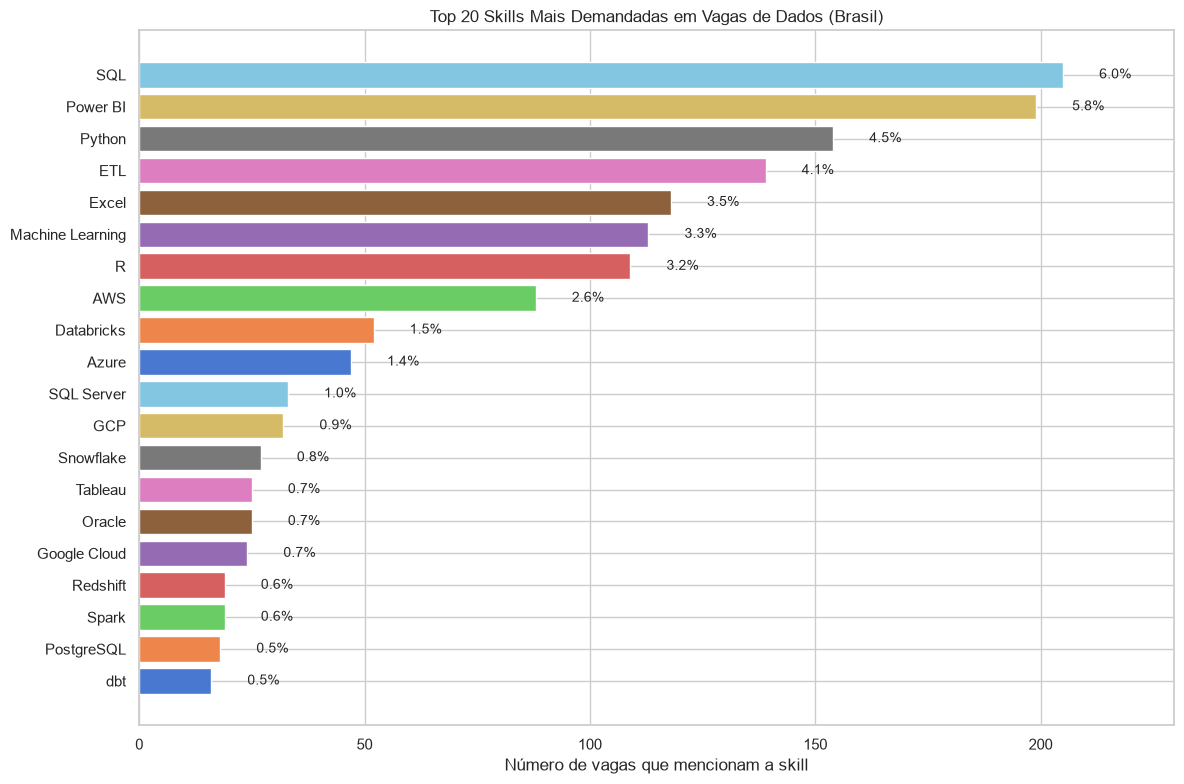

In [3]:
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=sns.color_palette("muted", len(top20)))

for bar, pct in zip(bars, top20_pct.values[::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height() / 2,
            f"{pct}%", va="center", fontsize=10)

ax.set_xlabel("Número de vagas que mencionam a skill")
ax.set_title("Top 20 Skills Mais Demandadas em Vagas de Dados (Brasil)")
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

---

## 2. Faixas salariais por senioridade

> **Nota:** os valores de salário retornados pela Adzuna são **anuais (R$/ano)**.

Filtramos apenas as vagas com `salary_avg` preenchido (não nulo) e agrupamos por senioridade. Como a amostra de salário é pequena (cerca de 5% das vagas), os resultados devem ser interpretados com cautela — especialmente para categorias com poucos registros.

In [4]:
df_sal = df[df["salary_avg"].notna()].copy()
print(f"Vagas com salário informado: {len(df_sal)} de {len(df)} ({len(df_sal)/len(df)*100:.1f}%)\n")

stats = df_sal.groupby("senioridade")["salary_avg"].agg(
    ["count", "mean", "median", "min", "max"]
).rename(columns={
    "count": "n",
    "mean": "média",
    "median": "mediana",
    "min": "mínimo",
    "max": "máximo",
}).sort_values("mediana", ascending=False)

print("Estatísticas de salary_avg (R$/ano) por senioridade:\n")
print(stats.round(0).to_string())

print("\n⚠️  Categorias com n < 15 devem ser interpretadas com cautela.")

Vagas com salário informado: 178 de 3409 (5.2%)

Estatísticas de salary_avg (R$/ano) por senioridade:

                    n     média   mediana   mínimo    máximo
senioridade                                                 
sênior             23   94938.0  106680.0   1224.0  162000.0
não especificado  123   97358.0   60000.0     12.0  885600.0
pleno              13   57501.0   54000.0  34536.0   78000.0
júnior              8  123692.0   46398.0  33000.0  612000.0
estágio            11   21794.0   24000.0  12000.0   30000.0

⚠️  Categorias com n < 15 devem ser interpretadas com cautela.


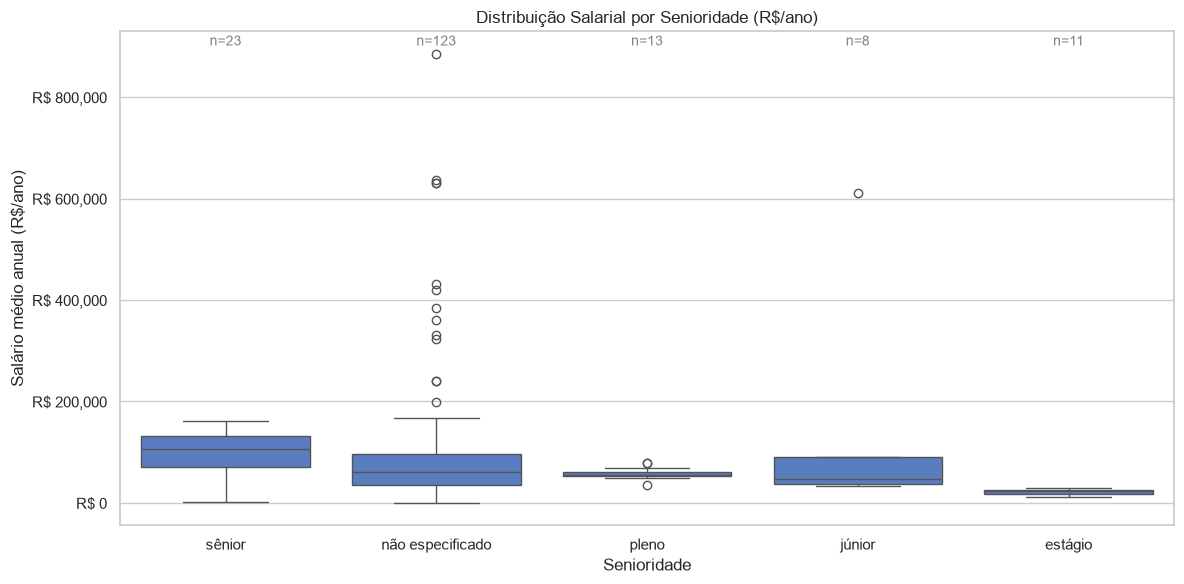

In [5]:
order = stats.index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_sal, x="senioridade", y="salary_avg", order=order, ax=ax)

for i, nivel in enumerate(order):
    n = int(stats.loc[nivel, "n"])
    ax.text(i, ax.get_ylim()[1] * 0.97, f"n={n}", ha="center", fontsize=10, color="gray")

ax.set_xlabel("Senioridade")
ax.set_ylabel("Salário médio anual (R$/ano)")
ax.set_title("Distribuição Salarial por Senioridade (R$/ano)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
plt.tight_layout()
plt.show()

**Observação sobre a categoria "Não especificado":** a mediana salarial desta categoria (R$ 60.000/ano) é superior à de "Pleno" (R$ 54.000/ano). Isso provavelmente ocorre porque vagas de nível sênior ou pleno que não indicam senioridade no título acabam agrupadas aqui, elevando a mediana. Além disso, os tamanhos amostrais são pequenos em todas as categorias específicas (n=8 a n=23), o que limita conclusões fortes sobre diferenças salariais entre níveis.

---

## 3. Distribuição geográfica e modalidade

### 3.1 Modalidade de trabalho

A modalidade foi inferida por palavras-chave explícitas no título e na descrição. Vagas sem menção explícita foram classificadas como "não especificado".

Distribuição de modalidade:

  não especificado      3017 (88.5%)
  remoto                 166 (4.9%)
  híbrido                131 (3.8%)
  presencial              95 (2.8%)


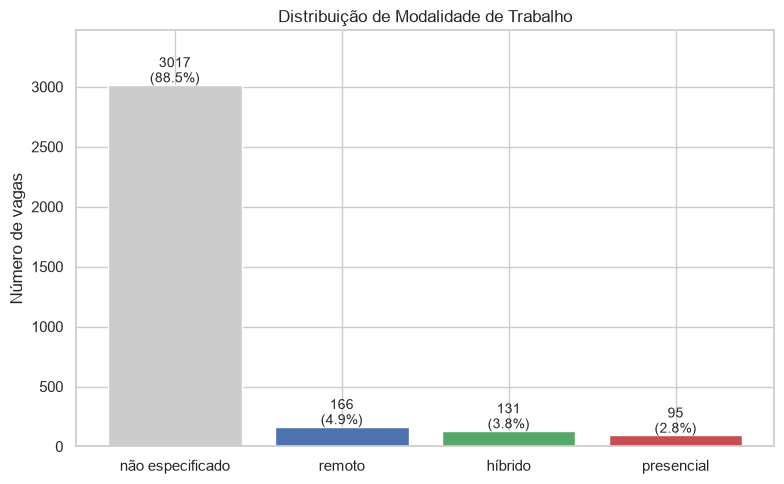

In [6]:
modalidade_counts = df["modalidade"].value_counts()

print("Distribuição de modalidade:\n")
for mod, count in modalidade_counts.items():
    pct = count / len(df) * 100
    print(f"  {mod:<20} {count:>5} ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
colors = {"remoto": "#4c72b0", "híbrido": "#55a868", "presencial": "#c44e52", "não especificado": "#cccccc"}
bar_colors = [colors.get(m, "#999999") for m in modalidade_counts.index]

bars = ax.bar(modalidade_counts.index, modalidade_counts.values, color=bar_colors)

for bar, count in zip(bars, modalidade_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{count}\n({pct:.1f}%)", ha="center", fontsize=10)

ax.set_ylabel("Número de vagas")
ax.set_title("Distribuição de Modalidade de Trabalho")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

### 3.2 Top 10 localidades

Usamos o campo `location_areas` (estrutura hierárquica `Brasil > Região > Estado > Cidade`) para extrair o **estado**. Vagas com localização apenas "Brasil" (sem estado específico) são agrupadas à parte.

Top 10 localidades (por estado):

  Estado de São Paulo             1480 (43.4%)
  Brasil                           888 (26.0%)
  Minas Gerais                     201 (5.9%)
  Estado do Rio de Janeiro         150 (4.4%)
  Rio Grande do Sul                134 (3.9%)
  Paraná                           116 (3.4%)
  Distrito Federal                  80 (2.3%)
  Ceará                             63 (1.8%)
  Santa Catarina                    56 (1.6%)
  Goiás                             44 (1.3%)


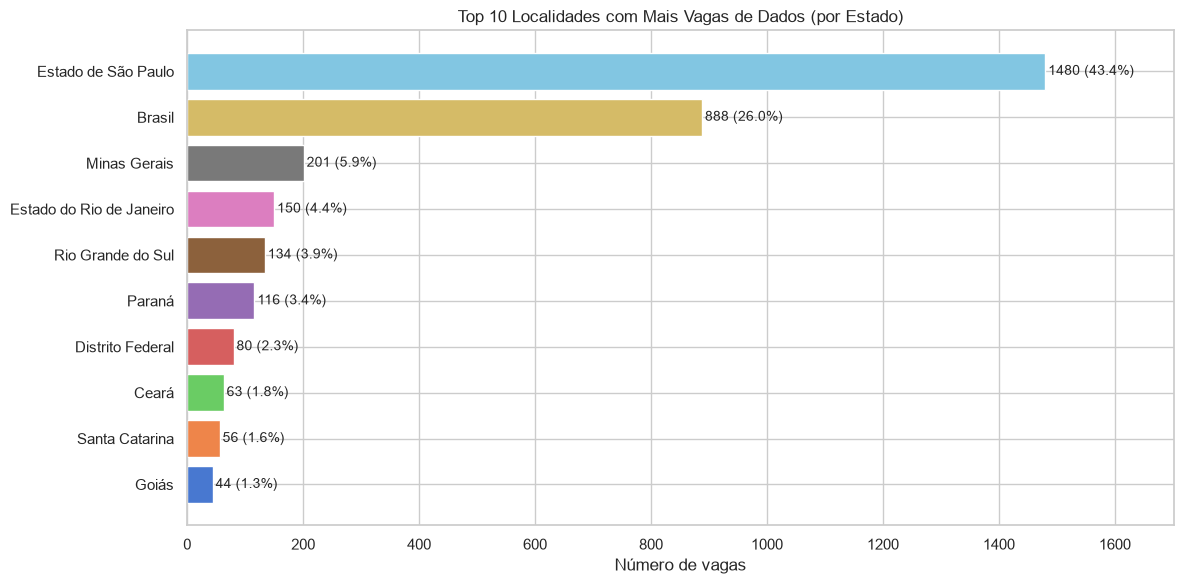

In [7]:
def extract_estado(location_areas: str) -> str:
    """Extrai o estado da hierarquia 'Brasil > Região > Estado > Cidade'."""
    parts = [p.strip() for p in str(location_areas).split(">")]
    if len(parts) >= 3:
        return parts[2]
    return parts[0]  # "Brasil" quando não há detalhamento

df["estado"] = df["location_areas"].apply(extract_estado)

estado_counts = df["estado"].value_counts().head(10)

print("Top 10 localidades (por estado):\n")
for estado, count in estado_counts.items():
    pct = count / len(df) * 100
    print(f"  {estado:<30} {count:>5} ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(estado_counts.index[::-1], estado_counts.values[::-1],
               color=sns.color_palette("muted", len(estado_counts)))

for bar in bars:
    pct = bar.get_width() / len(df) * 100
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())} ({pct:.1f}%)", va="center", fontsize=10)

ax.set_xlabel("Número de vagas")
ax.set_title("Top 10 Localidades com Mais Vagas de Dados (por Estado)")
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

**Nota sobre dados de localização:** aproximadamente 26% das vagas aparecem com localização genérica ("Brasil", sem estado específico). Isso é uma limitação de qualidade do dado de origem (a Adzuna nem sempre recebe a localização detalhada do anunciante), não um erro de processamento. Essas vagas podem ser remotas, nacionais, ou simplesmente não terem tido a localização preenchida pelo empregador.

---

## Resumo dos Achados

In [8]:
print("=" * 60)
print("RESUMO DOS ACHADOS")
print("=" * 60)

print(f"\nBase analisada: {len(df)} vagas únicas")

# Skills
print("\n1. SKILLS MAIS DEMANDADAS")
for i, (skill, count) in enumerate(top20.head(5).items(), 1):
    pct = count / len(df) * 100
    print(f"   {i}. {skill}: {count} vagas ({pct:.1f}%)")
print(f"   ... (top 20 completo no gráfico acima)")

# Salário
print(f"\n2. FAIXAS SALARIAIS POR SENIORIDADE")
print(f"   Apenas {len(df_sal)} vagas ({len(df_sal)/len(df)*100:.1f}%) informam salário.")
for nivel in stats.index:
    n = int(stats.loc[nivel, "n"])
    med = stats.loc[nivel, "mediana"]
    cautela = " ⚠️  (amostra pequena)" if n < 15 else ""
    print(f"   {nivel}: mediana R$ {med:,.0f} (n={n}){cautela}")

# Geografia
print(f"\n3. DISTRIBUIÇÃO GEOGRÁFICA E MODALIDADE")
print(f"   Modalidade:")
for mod, count in modalidade_counts.items():
    print(f"     {mod}: {count} ({count/len(df)*100:.1f}%)")
print(f"   Top 3 estados:")
for estado, count in estado_counts.head(3).items():
    print(f"     {estado}: {count} vagas ({count/len(df)*100:.1f}%)")

RESUMO DOS ACHADOS

Base analisada: 3409 vagas únicas

1. SKILLS MAIS DEMANDADAS
   1. SQL: 205 vagas (6.0%)
   2. Power BI: 199 vagas (5.8%)
   3. Python: 154 vagas (4.5%)
   4. ETL: 139 vagas (4.1%)
   5. Excel: 118 vagas (3.5%)
   ... (top 20 completo no gráfico acima)

2. FAIXAS SALARIAIS POR SENIORIDADE
   Apenas 178 vagas (5.2%) informam salário.
   sênior: mediana R$ 106,680 (n=23)
   não especificado: mediana R$ 60,000 (n=123)
   pleno: mediana R$ 54,000 (n=13) ⚠️  (amostra pequena)
   júnior: mediana R$ 46,398 (n=8) ⚠️  (amostra pequena)
   estágio: mediana R$ 24,000 (n=11) ⚠️  (amostra pequena)

3. DISTRIBUIÇÃO GEOGRÁFICA E MODALIDADE
   Modalidade:
     não especificado: 3017 (88.5%)
     remoto: 166 (4.9%)
     híbrido: 131 (3.8%)
     presencial: 95 (2.8%)
   Top 3 estados:
     Estado de São Paulo: 1480 vagas (43.4%)
     Brasil: 888 vagas (26.0%)
     Minas Gerais: 201 vagas (5.9%)
